# Interactive plot: test system - comparison to ground truth

In [10]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import os
import hyperspy.api as hs
from matplotlib.colors import to_rgba, LinearSegmentedColormap, ListedColormap

%matplotlib widget
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.path import Path
from matplotlib.patches import PathPatch
from IPython.display import display
from ipywidgets import Checkbox, Dropdown, FloatRangeSlider, Layout, HBox, VBox, interactive

In [2]:
plt.rcParams['figure.figsize'] = (3, 2)
plt.rcParams.update({'font.size': 8})
plt.rcParams['figure.dpi'] = 150

time0=time()

# 1. Load data to plot

In [5]:
folder_data = '.\\data\\'
gt = hs.load(folder_data + 'ground_truth.hspy')

file_names = []
diffs = []
diffs_names = []
phase_maps = []
phase_maps_names = []

for root, dirs, files in os.walk(folder_data):
    for file in files:
        file_names.append(file[:-5])
        if file.startswith('diff_'):
            diff = hs.load(folder_data+file)
            diffs.append(diff)
            diffs_names.append(file[:-5])
        elif file.startswith('phase_map_') and file.endswith('_gt.hspy'):
            phase_map = hs.load(folder_data+file)
            phase_maps.append(phase_map)
            phase_maps_names.append(file[:-5])

diff:  diff_nmf.hspy
diff:  diff_nmf_p.hspy
diff:  diff_sel.hspy
diff:  diff_sel_p.hspy
diff:  diff_sim.hspy
diff:  diff_sim_p.hspy
phase_map:  phase_map_nmf_gt.hspy
phase_map:  phase_map_nmf_p_gt.hspy
phase_map:  phase_map_sel_gt.hspy
phase_map:  phase_map_sel_p_gt.hspy
phase_map:  phase_map_sim_gt.hspy
phase_map:  phase_map_sim_p_gt.hspy


In [7]:
phase_names = [
    'tp_001', # theta' <001> 'blob' 
    'tp_100-1', # theta' <100> 'needle' 1
    'tp_100-2', # theta' <100> 'needle' 2
    't1-1', # T1 'rectangle' 1
    't1-2', # T1 'rectangle' 2
]

colors = ('cornflowerblue', 
          'orange', 
          'salmon', 
          'seagreen', 
          'darkseagreen', 
         )
colors_rgba = [to_rgba(c) for c in colors]

names_gt = ['Al', r'$\theta^{\prime}_{100}$', r'$\theta^{\prime}_{001}$', 'T$_1$']
color_names_gt = ['linen', 'darkorange', 'dodgerblue', 'forestgreen']
colors_gt = [to_rgba(c) for c in color_names_gt]
cmap_gt = LinearSegmentedColormap.from_list('gt_cmap', colors_gt, N=len(color_names_gt))

diff_cmap = ListedColormap(['white', 'black'])

interactive(children=(Dropdown(description='Templates:', layout=Layout(width='250px'), options=('A: simulated'…

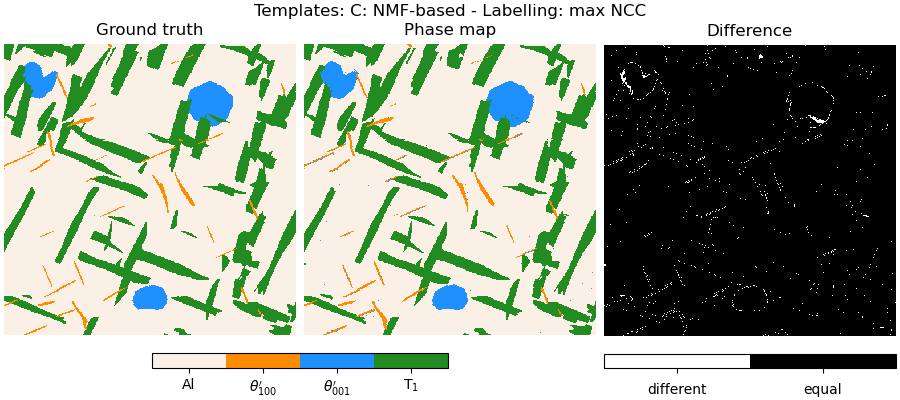

In [15]:
fig = plt.figure(layout='constrained', figsize=(9, 4))

subfigs = fig.subfigures(1, 2, wspace=0.0, width_ratios=[2, 1])
ax = subfigs[0].subplots(1, 2)
ax[0].axis('off')
gt_ax = ax[0].imshow(gt.data, cmap=cmap_gt, interpolation='none')
ax[0].set_title('Ground truth')
ax[1].axis('off')
phase_map_ax = ax[1].imshow(phase_maps[0].data, cmap=cmap_gt, interpolation='none')
ax[1].set_title('Phase map')
cbar = subfigs[0].colorbar(gt_ax, shrink=0.5, ax=ax, location='bottom')
yticks = [0.5, 1.5, 2.5, 3.5]
cbar.set_ticks(yticks, labels=names_gt)

axd = subfigs[1].subplots(1, 1)
axd.axis('off')
diff_ax = axd.imshow(diffs[0].data, cmap=diff_cmap, interpolation='none')
axd.set_title('Difference')
cbar_ = subfigs[1].colorbar(diff_ax, ax=axd, location='bottom')
yticks_diff = [0.25, 0.75]
cbar_.set_ticks(yticks_diff, labels=['different', 'equal'])
cbar_.ax.tick_params(color='black', labelcolor='black', pad=7.1)

fig.canvas.resizable = False
fig.canvas.header_visible = False
fig.canvas.footer_visible = False
fig.canvas.toolbar_visible = True
fig.canvas.toolbar_position = 'top'

i, j = 0, 0
templates = ['A: simulated', 'B: selected', 'C: NMF-based']
labelling = ['max NCC', 'priority']

fig.suptitle('Templates: ' + templates[i] + ' - Labelling: ' + labelling[j], fontsize='large')

def update_plots(tw, lw):
    if tw[0] == 'A':
        i = 2
    elif tw[0] == 'B':
        i = 1
    elif tw[0] == 'C':
        i = 0
    if lw[0] == 'm':
        j = 0
    elif lw[0] == 'p':
        j = 1
    fig.suptitle('Templates: ' + templates[i] + ' - Labelling: ' + labelling[j], fontsize='large')
    phase_map_ax.set_data(phase_maps[i+j])
    diff_ax.set_data(diffs[i+j])
    fig.canvas.draw_idle()
    return None

template_widget = Dropdown(options=templates, description='Templates:', layout=Layout(width='250px'), disabled=False)
labelling_widget = Dropdown(options=labelling, description='Phase labelling: ', layout=Layout(width='250px'), disabled=False)
wid = interactive(update_plots, tw=template_widget, lw=labelling_widget)
display(wid)